In [1]:
from dotenv import load_dotenv
import os
load_dotenv()  # reads your .env file and loads variables into memory


from openai import OpenAI
from pydantic import BaseModel
from typing import List

# Load environment variables from .env file
load_dotenv()

# Access them like any environment variable
db_url = os.getenv("DATABASE_URL")
debug = os.getenv("DEBUG")
api_key = os.getenv("OPENAI_API_KEY")  # adjust name if yours is different
print("Key loaded:", api_key is not None)  # just checks it worked, doesn't print the actual key
# Initialize OpenAI client securely from environment variable
client = OpenAI(api_key=api_key)
response = client.responses.create(
    model="gpt-4o",
    input="What is machine learning?"
)

print(response.output_text)


Key loaded: True
Machine learning is a subset of artificial intelligence (AI) that focuses on developing algorithms and statistical models that enable computers to perform tasks without explicit instructions. Instead, systems learn from patterns and experiences (data) to make decisions or predictions. Key approaches include:

1. **Supervised Learning**: The model learns from labeled data to make predictions, such as classifying images or forecasting prices.

2. **Unsupervised Learning**: The model identifies patterns or structures in unlabeled data, such as clustering similar documents or finding anomalies.

3. **Reinforcement Learning**: The model learns by interacting with an environment, receiving feedback through rewards or penalties, like in game-playing or robotics.

Machine learning is used in various applications, including recommendation systems, natural language processing, and autonomous vehicles.


In [7]:
# Install: pip install datasets
from datasets import load_dataset
import requests
from PIL import Image
import pandas as pd
from pathlib import Path
 
# Load dataset from HuggingFace
print("Loading product dataset...")
try:
    # Try loading the dataset
    dataset = load_dataset("ashraq/fashion-product-images-small", split="train[:20]")  # First 100 samples
    print(f"✓ Loaded {len(dataset)} products")
    
    # Convert to pandas for easier manipulation
    products_df = pd.DataFrame(dataset)
    print(f"Dataset columns: {products_df.columns.tolist()}")
    
except Exception as e:
    print(f"⚠ Could not load HuggingFace dataset: {e}")
    print("Using local images instead...")
    
    # Alternative: Use local images
    # Create a products.json file with product information
        # Add more products...
    
 
# Create images directory
images_dir = Path("product_images")
images_dir.mkdir(exist_ok=True)
 
print(f"\n✓ Dataset prepared!")
print(f"  Total products: {len(products_df)}")

Loading product dataset...
✓ Loaded 20 products
Dataset columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image']

✓ Dataset prepared!
  Total products: 20


In [8]:
import base64
from io import BytesIO
def encode_image_to_base64(pil_image):
    """Encode a PIL Image object to base64 string."""
    buffered = BytesIO()
    pil_image.save(buffered, format="JPEG")
    encoded = base64.b64encode(buffered.getvalue()).decode("utf-8")
    return encoded
# Example usage — use the "image" column, not "image_path"
sample_image = products_df.iloc[0]["image"]
encoded_image = encode_image_to_base64(sample_image)
print(f"Encoded image length: {len(encoded_image)} characters")
print(f"Encoded prefix: {encoded_image[:40]}...")

Encoded image length: 2400 characters
Encoded prefix: /9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcG...


In [9]:
def create_product_listing_prompt(product_name, price, category, additional_info=None):
    """
    Create a prompt for generating product listings.
    
    Parameters:
    - product_name: Name of the product
    - price: Price of the product
    - category: Product category
    - additional_info: Optional additional information
    
    Returns:
    - Formatted prompt string
    """
    prompt = f"""You are an expert e-commerce copywriter. Analyze the product image and create a compelling product listing.
 
Product Information:
- Name: {product_name}
- Price: ${price:.2f}
- Category: {category}
{f'- Additional Info: {additional_info}' if additional_info else ''}
 
Please create a professional product listing that includes:
 
1. **Product Title** (catchy, SEO-friendly, 60 characters max)
2. **Product Description** (detailed, 150-200 words)
   - Highlight key features and benefits
   - Use persuasive language
   - Include relevant details visible in the image
3. **Key Features** (bullet points, 5-7 items)
4. **SEO Keywords** (comma-separated, 10-15 relevant keywords)
 
Format your response as JSON with the following structure:
{{
    "title": "Product title here",
    "description": "Full description here",
    "features": ["Feature 1", "Feature 2", ...],
    "keywords": "keyword1, keyword2, ..."
}}
 
Be specific about what you see in the image. Mention colors, materials, design elements, and any distinctive features."""
    
    return prompt
 
# Test prompt creation
test_prompt = create_product_listing_prompt(
    product_name="Wireless Bluetooth Headphones",
    price=79.99,
    category="Electronics",
    additional_info="Noise cancelling, 30-hour battery"
)
 
print("\n" + "="*50)
print("PROMPT TEMPLATE")
print("="*50)
print(test_prompt[:500] + "...")  # Show first 500 characters


PROMPT TEMPLATE
You are an expert e-commerce copywriter. Analyze the product image and create a compelling product listing.

Product Information:
- Name: Wireless Bluetooth Headphones
- Price: $79.99
- Category: Electronics
- Additional Info: Noise cancelling, 30-hour battery

Please create a professional product listing that includes:

1. **Product Title** (catchy, SEO-friendly, 60 characters max)
2. **Product Description** (detailed, 150-200 words)
   - Highlight key features and benefits
   - Use persuasive ...


In [10]:
from openai import OpenAI
from dotenv import load_dotenv
import json
import os
import re

# Load API key from .env
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=api_key)


def clean_json_response(text):
    """Removes markdown code fences (```json ... ```) if present."""
    text = text.strip()
    text = re.sub(r"^```json\s*", "", text)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"```$", "", text)
    return text.strip()


def get_product_listing(pil_image, product_name, price, category, additional_info=None):
    """
    Sends the product image + a text prompt to ChatGPT, and gets back
    a generated product listing.
    """
    # Step A: turn the picture into base64 text
    encoded_image = encode_image_to_base64(pil_image)

    # Step B: build the instructions
    prompt = create_product_listing_prompt(product_name, price, category, additional_info)

    # Step C: send both the text and the image to ChatGPT
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{encoded_image}"
                    }
                    }
                ]
            }
        ],
        max_tokens=800,
        response_format={"type": "json_object"}   # forces clean JSON, no markdown wrapper
    )

    # Step D: get ChatGPT's reply as plain text
    reply_text = response.choices[0].message.content

    # Step E: turn that text into a real Python dictionary
    cleaned_text = clean_json_response(reply_text)
    try:
        listing = json.loads(cleaned_text)
    except json.JSONDecodeError:
        print("⚠ Could not parse JSON, here's the raw reply:")
        print(reply_text)
        listing = None

    return listing   # <-- this was missing before


# Test it on one product
row = products_df.iloc[0]
result = get_product_listing(
    pil_image=row["image"],
    product_name=row["productDisplayName"],
    price=29.99,
    category=row["masterCategory"]
)
print(result)


{'title': "Stylish Navy Blue Checkered Men's Shirt", 'description': 'Elevate your wardrobe with the Turtle Check Men Navy Blue Shirt, a blend of modern style and all-day comfort. This premium shirt features a sophisticated navy blue checkered pattern, perfect for both casual and semi-formal settings. Crafted from high-quality, breathable fabric, it ensures you stay cool and confident all day long. The tailored fit accentuates your physique while providing ample mobility. Its versatile design makes it a great match for jeans or chinos, allowing you to effortlessly transition from office meetings to weekend outings. With its timeless appeal and impeccable construction, this shirt is a must-have for any fashion-forward individual.', 'features': ['Navy blue checkered pattern', 'Comfortable, breathable fabric', 'Tailored fit for enhanced style', 'Versatile for various occasions', 'Easy to pair with jeans or chinos', 'Durable and long-lasting material', 'Available in multiple sizes'], 'keywo

In [11]:
import time
import json

def process_all_products(df, num_products=5):
    """
    Runs get_product_listing() for several products in a row,
    and saves all the results.
    """
    all_results = []

    for i in range(num_products):
        row = df.iloc[i]
        print(f"Processing product {i+1}/{num_products}: {row['productDisplayName']}")

        try:
            listing = get_product_listing(
                pil_image=row["image"],
                product_name=row["productDisplayName"],
                price=29.99,  # you can adjust this later
                category=row["masterCategory"]
            )

            if listing:
                listing["product_id"] = int(row["id"])
                all_results.append(listing)
                print("  ✓ Success")

        except Exception as e:
            print(f"  ✗ Error: {e}")

        time.sleep(1)  # small pause so we don't send requests too fast

    return all_results


# Run it on your first 5 products
results = process_all_products(products_df, num_products=5)

# Save everything to a file
with open("product_listings.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"\nDone! Saved {len(results)} listings to product_listings.json")

Processing product 1/5: Turtle Check Men Navy Blue Shirt
  ✓ Success
Processing product 2/5: Peter England Men Party Blue Jeans
  ✓ Success
Processing product 3/5: Titan Women Silver Watch
  ✓ Success
Processing product 4/5: Manchester United Men Solid Black Track Pants
  ✓ Success
Processing product 5/5: Puma Men Grey T-shirt
  ✓ Success

Done! Saved 5 listings to product_listings.json


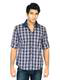

In [14]:
products_df["image"][0]

